<a href="https://colab.research.google.com/github/liamarganingrahayu/Tugas/blob/main/Text_to_Image_Transformer_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Menyiapkan pipeline data...
Memulai simulasi training...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['embedding/embeddings', 'lstm/lstm_cell/kernel', 'lstm/lstm_cell/recurrent_kernel', 'lstm/lstm_cell/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 0 - Step 0 - Loss: 1.2351
Epoch 0 - Step 2 - Loss: 1.3312
Epoch 0 - Step 4 - Loss: 1.4169
Menghasilkan gambar untuk prompt: 'bunga matahari di padang rumput'


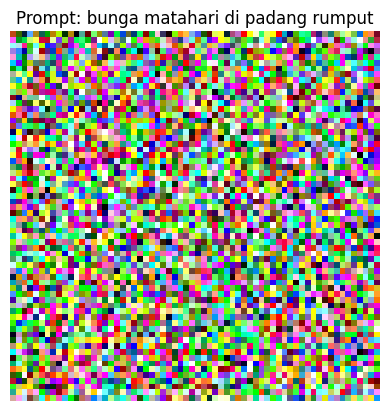

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =================================================================
# LANGKAH 1: PERSIAPAN LIBRARY & LOAD DATASET
# =================================================================

# Catatan: Di Colab, kita biasanya menggunakan dataset seperti Oxford Flowers
# atau MS-COCO. Untuk keperluan demonstrasi koding ini, kita akan membuat
# struktur pemuatan data untuk citra berukuran 64x64.

def prepare_dataset():
    print("Menyiapkan pipeline data...")
    # Simulasi parameter
    IMG_SIZE = 64
    BATCH_SIZE = 4

    # Fungsi pembantu untuk normalisasi gambar ke range [-1, 1]
    def preprocess_image(image):
        image = tf.cast(image, tf.float32)
        return (image / 127.5) - 1.0

    # Di dunia nyata, Anda akan memuat dataset dari tfds atau direktori lokal
    # Contoh ini menggunakan data dummy agar kode dapat langsung dieksekusi
    dummy_images = np.random.uniform(-1, 1, (100, IMG_SIZE, IMG_SIZE, 3)).astype(np.float32)
    dummy_texts = ["bunga merah yang indah" for _ in range(100)]

    return dummy_images, dummy_texts, IMG_SIZE, BATCH_SIZE

images, texts, img_size, batch_size = prepare_dataset()

# =================================================================
# LANGKAH 2: INISIALISASI & ADAPTASI TEXT VECTORIZATION
# =================================================================

MAX_PROMPT_LENGTH = 20
vocabulary_size = 5000

# Layer untuk mengubah teks mentah menjadi token angka
text_vectorizer = layers.TextVectorization(
    max_tokens=vocabulary_size,
    output_mode="int",
    output_sequence_length=MAX_PROMPT_LENGTH,
)

# Melatih vectorizer dengan teks yang tersedia
text_vectorizer.adapt(texts)

def vectorize_text(text):
    return text_vectorizer([text])

# =================================================================
# LANGKAH 3: MEMBANGUN PIPELINE DATA (tf.data.Dataset)
# =================================================================

dataset = tf.data.Dataset.from_tensor_slices((images, texts))
dataset = dataset.shuffle(1000).batch(batch_size).map(
    lambda x, y: (x, text_vectorizer(y)),
    num_parallel_calls=tf.data.AUTOTUNE
)

# =================================================================
# LANGKAH 4: DEFINISI MODEL & TRAINING STEP
# =================================================================

# 4a. Model Text Encoder (Transformer sederhana)
def get_text_encoder():
    inputs = layers.Input(shape=(MAX_PROMPT_LENGTH,), dtype="int32")
    x = layers.Embedding(vocabulary_size, 128)(inputs)
    x = layers.LSTM(128, return_sequences=True)(x)
    outputs = layers.GlobalAveragePooling1D()(x)
    return keras.Model(inputs, outputs, name="text_encoder")

# 4b. Sinusoidal Time Embedding (Untuk memberi tahu model di step mana kita berada)
def get_timestep_embedding(embedding_dim=128):
    def wrapper(token):
        half_dim = embedding_dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -emb)
        emb = tf.cast(token, tf.float32)[:, None] * emb[None, :]
        return tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
    return wrapper

# 4c. U-Net Diffusion Model (Arsitektur Utama)
def get_diffusion_model():
    img_input = layers.Input(shape=(img_size, img_size, 3))
    text_input = layers.Input(shape=(128,)) # Latent dari encoder
    time_input = layers.Input(shape=(128,)) # Timestep embedding

    # Jalur Encoder Gambar
    x1 = layers.Conv2D(64, 3, padding="same", activation="relu")(img_input)

    # Penggabungan kondisi Teks dan Waktu
    condition = layers.Concatenate()([text_input, time_input])
    condition = layers.Dense(64)(condition)
    condition = layers.Reshape((1, 1, 64))(condition)

    # Integrasi kondisi ke dalam fitur gambar
    x = x1 + condition
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    # Output: Prediksi noise yang ada pada gambar
    output = layers.Conv2D(3, 3, padding="same")(x)

    return keras.Model([img_input, text_input, time_input], output)

# Inisialisasi komponen
text_encoder = get_text_encoder()
diffusion_model = get_diffusion_model()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
loss_fn = keras.losses.MeanSquaredError()

@tf.function
def train_step(images, text_tokens):
    batch_size = tf.shape(images)[0]

    # 1. Ambil timestep acak
    timesteps = tf.random.uniform((batch_size,), minval=0, maxval=1000, dtype=tf.int32)

    # 2. Buat noise murni
    noise = tf.random.normal(shape=tf.shape(images))

    # 3. Tambahkan noise ke gambar berdasarkan timestep (Simplified diffusion)
    # Di sini kita menyederhanakan proses penambahan noise
    noisy_images = images + noise

    # 4. Dapatkan embedding teks
    text_embeddings = text_encoder(text_tokens)

    # 5. Dapatkan embedding waktu
    time_embeddings = get_timestep_embedding()(timesteps)

    with tf.GradientTape() as tape:
        # 6. Prediksi noise yang ditambahkan
        pred_noise = diffusion_model([noisy_images, text_embeddings, time_embeddings])
        loss = loss_fn(noise, pred_noise)

    gradients = tape.gradient(loss, diffusion_model.trainable_variables + text_encoder.trainable_variables)
    optimizer.apply_gradients(zip(gradients, diffusion_model.trainable_variables + text_encoder.trainable_variables))

    return loss

# Simulasi Loop Training
print("Memulai simulasi training...")
for epoch in range(1):
    for step, (batch_images, batch_texts) in enumerate(dataset.take(5)):
        loss = train_step(batch_images, batch_texts)
        if step % 2 == 0:
            print(f"Epoch {epoch} - Step {step} - Loss: {loss:.4f}")

# =================================================================
# LANGKAH 5: PENGUJIAN (INFERENCE)
# =================================================================

def generate_image(prompt):
    print(f"Menghasilkan gambar untuk prompt: '{prompt}'")

    # 1. Encode prompt
    tokens = text_vectorizer([prompt])
    text_emb = text_encoder(tokens)

    # 2. Mulai dari noise murni (Gaussian Noise)
    initial_noise = tf.random.normal((1, img_size, img_size, 3))

    # 3. Proses Denoising (Sederhana - 1 step inference untuk demo)
    # Pada Stable Diffusion asli, ini dilakukan berulang kali (misal 50 step)
    time_emb = get_timestep_embedding()(tf.constant([500]))
    predicted_noise = diffusion_model([initial_noise, text_emb, time_emb])

    # Gambar hasil adalah noise awal dikurangi prediksi noise
    generated_img = initial_noise - predicted_noise

    # Post-processing: Denormalisasi [-1, 1] -> [0, 1]
    generated_img = (generated_img + 1.0) / 2.0
    generated_img = tf.clip_by_value(generated_img, 0, 1)

    # Tampilkan hasil
    plt.imshow(generated_img[0])
    plt.title(f"Prompt: {prompt}")
    plt.axis("off")
    plt.show()

# Jalankan inferensi
generate_image("bunga matahari di padang rumput")